In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from shared.utils import u_style, u_stats
from shared.LMCS import glob_util
from shared.paths import load_paths
from scipy.stats import linregress
import os


u_style.set_mpl_style()

%matplotlib inline

In [7]:
REGIONS = glob_util.REGIONS
style = glob_util.REGION_STYLE


paths = load_paths()
ROOT = paths.datasets["obs_mcs_5000km2_tables_ERA"]
print("Using ROOT:", ROOT)
YEARS = range(2000, 2020)

Using ROOT: /prj/global_water/MCS_5000km2_tables_v3/ERA5_storm_timeseries


In [8]:

region_groups = {
    "GPlains": "midlat",
    "Eur": "midlat",
    "china": "midlat",
    "SAf": "midlat",
    "subSA": "midlat",

    "tropSA": "tropics",
    "WAf": "tropics",
    "CAf": "tropics",
    "EAf": "tropics",
    "australia": "tropics",
    "india": "tropics",

    "Atl": "ocean",
    "Pcf": "ocean",
    "InO": "ocean"
}

In [9]:
def read_meta(region):
    files = [
        f"{ROOT}/storm_metadata/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [pd.read_parquet(f) for f in files],
        ignore_index=True
    )


def read_var(var, region):
    files = [
        f"{ROOT}/{var}/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [
            pd.read_parquet(
                f,
                columns=["storm_id", "rel_hour", "value"]
            )
            for f in files
        ],
        ignore_index=True
    )


def region_df(region, rel_hour=0):
    df = read_meta(region).copy()

    for var in ERA_VARS:
        tmp = read_var(var, region)

        tmp = (
            tmp[tmp["rel_hour"] == rel_hour]
            [["storm_id", "value"]]
            .drop_duplicates("storm_id")
            .rename(columns={"value": var})
        )

        df = df.merge(tmp, on="storm_id", how="left")

    df["region"] = region

    return df

def build_all_regions(variables):

    dfs = []

    for region in REGIONS:

        meta = read_meta(region)

        if meta is None:
            continue

        df = None

        for var in variables:

            tmp = read_var(var, region)

            tmp = tmp.rename(columns={"value": var})

            if df is None:
                df = tmp
            else:
                df = df.merge(
                    tmp[["storm_id", "rel_hour", var]],
                    on=["storm_id", "rel_hour"],
                    how="outer",
                )

        df = df.merge(meta, on="storm_id", how="left")

        df["region"] = region

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [18]:
def compute_beta_table(
    df,
    humidity_var="tcwv",
    shear_var="shear100_650",
    response_var="precipitation_max",
    humidity_bins=np.arange(20, 81, 5),
    min_n=100,
):
    rows = []
    mids = 0.5 * (humidity_bins[:-1] + humidity_bins[1:])

    def fit_one_subset(sub, region_name, lo, hi, mid):
        sub = sub.dropna(subset=[humidity_var, shear_var, response_var])

        if len(sub) < min_n:
            return None

        # Need actual variation in shear and response
        if sub[shear_var].nunique() < 2 or sub[response_var].nunique() < 2:
            return None

        fit = linregress(
            sub[shear_var],
            sub[response_var],
        )

        return {
            "region": region_name,
            "humidity_bin_low": lo,
            "humidity_bin_high": hi,
            "humidity_mid": mid,
            "beta": fit.slope,
            "beta_stderr": fit.stderr,
            "beta_low95": fit.slope - 1.96 * fit.stderr,
            "beta_high95": fit.slope + 1.96 * fit.stderr,
            "intercept": fit.intercept,
            "r": fit.rvalue,
            "r2": fit.rvalue ** 2,
            "p": fit.pvalue,
            "n": len(sub),
            "response_var": response_var,
            "humidity_var": humidity_var,
            "shear_var": shear_var,
        }

    # pooled fit
    for lo, hi, mid in zip(humidity_bins[:-1], humidity_bins[1:], mids):
        sub = df[(df[humidity_var] >= lo) & (df[humidity_var] < hi)]
        out = fit_one_subset(sub, "pooled", lo, hi, mid)
        if out is not None:
            rows.append(out)

    # region-by-region fit
    for region in sorted(df["region"].dropna().unique()):
        rdf = df[df["region"] == region]

        for lo, hi, mid in zip(humidity_bins[:-1], humidity_bins[1:], mids):
            sub = rdf[(rdf[humidity_var] >= lo) & (rdf[humidity_var] < hi)]
            out = fit_one_subset(sub, region, lo, hi, mid)
            if out is not None:
                rows.append(out)

    return pd.DataFrame(rows)

In [10]:
df_all = pd.read_parquet(paths.shear_data + '/reduced_shear_study_data.parquet')

In [11]:
df_all.keys()

Index(['storm_id', 'rel_hour', 'tcwv', 'shear100_650', 'u650', 'ushear100_650',
       'q925', 'cape', 'date', 'month', 'hour', 'minute', 'year', 'day',
       'area', 'area70', 'area60', 'area50', 'minlon', 'minlat', 'maxlon',
       'maxlat', 'clon', 'clat', 'tminlon', 'tminlat', 'tmin', 'tmean', 'tp1',
       'tp99', 'stormID', 'shape_complexity', 'major_axis_km', 'minor_axis_km',
       'aspect_ratio', 'precipitation_mean', 'precipitation_max',
       'precipitation_p80', 'precipitation_p90', 'precipitation_p95',
       'precipitation_p99', 'precipitation_area1mm', 'precipitation_area3mm',
       'precipitation_area8mm', 'region', 'storm_utc_time', 'storm_lt_time',
       'storm_utc_hour', 'storm_lt_hour', 'lsm', 'topographic_complexity',
       'topographic_complexity_sdfor_slor', 'rh650', 'iwv_925_750',
       'qmean_925_750'],
      dtype='str')

In [12]:
df_all['precipitation_max'].min()

1.0

In [13]:
df_storm = df_all[(df_all["rel_hour"] == 0)].copy() # &
df_env = df_all[(df_all["rel_hour"] == -3) ].copy() # &

print(len(df_all), "storms before filtering")
print(len(df_env), "storms after filtering")
df_storm = df_storm.dropna(subset=["precipitation_p99","precipitation_max", "area","area50", "area60", "precipitation_area1mm", "precipitation_area8mm", "tcwv", "shear100_650", "q925", "cape", "iwv_925_750"])
df_env = df_env.dropna(subset=["precipitation_p99","precipitation_max", "area","area50", "area60", "precipitation_area1mm", "precipitation_area8mm", "tcwv", "shear100_650", "q925", "cape", "iwv_925_750"])

df_storm['q925'] = df_storm['q925'] * 1000
df_env['q925'] = df_env['q925'] * 1000

19425083 storms before filtering
1949541 storms after filtering


In [14]:
df_env_land = df_env[~df_env["region"].isin(["Atl", "Pcf", "InO"])]
df_env_ocean = df_env[df_env["region"].isin(["Atl", "Pcf", "InO"])]
df_env_midlat = df_env[df_env["region"].isin(["GPlains", "Eur", "china", "SAf", "subSA"])]
df_env_tropics = df_env[df_env["region"].isin(["tropSA", "WAf", "CAf", "EAf", "australia", "india"])] 

In [15]:
def plot_beta_summary(
    beta_df,
    ylabel,
    xlabel="TCWV (mm)",
    title="plot_beta_summary",
    out = "plot_beta_summary.png"
):

    pooled = beta_df[
        beta_df["region"] == "pooled"
    ].sort_values("humidity_mid")

    regional = beta_df[
        beta_df["region"] != "pooled"
    ]

    bins = pooled["humidity_mid"].values

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # ==========================================
    # Panel A: beta
    # ==========================================

    violin_data = []

    for b in bins:

        violin_data.append(
            regional.loc[
                regional["humidity_mid"] == b,
                "beta"
            ].dropna().values
        )

    bin_spacing = np.median(np.diff(bins))
    violin_width = 0.6 * bin_spacing

    ax1.violinplot(
        violin_data,
        positions=bins,
        widths=violin_width,
        showmedians=True,
    )

    # pooled CI

    ax1.fill_between(
        pooled["humidity_mid"],
        pooled["beta_low95"],
        pooled["beta_high95"],
        alpha=0.25,
        color="black",
    )

    # pooled beta

    ax1.plot(
        pooled["humidity_mid"],
        pooled["beta"],
        color="black",
        lw=2,
        marker="o",
        label="Pooled"
    )

    ax1.axhline(
        0,
        ls="--",
        c="0.5"
    )

    ax1.set_ylabel(ylabel)

    ax1.legend()
    plt.title(title)

    # ==========================================
    # Panel B: fit quality
    # ==========================================

    ax2.plot(
        pooled["humidity_mid"],
        pooled["r"],
        marker="o",
        color="black",
    )

    ax2.set_ylabel(r"$R^2$")

    # storm counts

    # for _, row in pooled.iterrows():

    #     ax2.text(
    #         row["humidity_mid"],
    #         row["p"] + 0.01,
    #         f"{int(row['n'])}",
    #         fontsize=8,
    #         ha="center",
    #     )

    ax2.set_xlabel(xlabel)

    plt.tight_layout()
    #plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()


In [19]:
def plot_beta_summary_groups(
    beta_groups,
    ylabel,
    xlabel="TCWV",
):
    """
    beta_groups: dict like
        {
            "All": beta_all,
            "Ocean": beta_ocean,
            "Midlat": beta_midlat,
            "Tropics": beta_tropics,
        }

    Each beta table should come from compute_beta_table()
    and contain a 'pooled' region row.
    """

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    for label, beta_df in beta_groups.items():

        pooled = (
            beta_df[beta_df["region"] == "pooled"]
            .sort_values("humidity_mid")
        )

        if len(pooled) == 0:
            print(f"No pooled data for {label}")
            continue

        # -----------------------------
        # Panel A: beta + CI
        # -----------------------------

        ax1.fill_between(
            pooled["humidity_mid"],
            pooled["beta_low95"],
            pooled["beta_high95"],
            alpha=0.15,
        )

        ax1.plot(
            pooled["humidity_mid"],
            pooled["beta"],
            marker="o",
            lw=2,
            label=label,
        )

        # -----------------------------
        # Panel B: r2 + n labels
        # -----------------------------

        ax2.plot(
            pooled["humidity_mid"],
            pooled["r2"],
            marker="o",
            lw=2,
            label=label,
        )

        for _, row in pooled.iterrows():
            ax2.text(
                row["humidity_mid"],
                row["r2"],
                f"{int(row['n'])}",
                fontsize=7,
                ha="center",
                va="bottom",
            )

    ax1.axhline(0, color="0.5", ls="--", lw=0.8)

    ax1.set_ylabel(ylabel)
    ax1.legend(fontsize=9)

    ax2.set_ylabel(r"$R^2$")
    ax2.set_xlabel(xlabel)

    plt.tight_layout()

    return fig, (ax1, ax2)

In [27]:
hvar = "iwv_925_750"
rvar='precipitation_max'
hum_bin = np.linspace(df_env[hvar].quantile(0.02), df_env[hvar].quantile(0.98), 12)  

beta_all_pr = compute_beta_table(
    df_env,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var="precipitation_max",
    humidity_bins=hum_bin
)

beta_ocean_pr = compute_beta_table(
    df_env_ocean,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var="precipitation_max",
    humidity_bins=hum_bin
)

beta_midlat_pr = compute_beta_table(
    df_env_midlat,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var="precipitation_max",
    humidity_bins=hum_bin,
)

beta_tropics_pr = compute_beta_table(
    df_env_tropics,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var="precipitation_max",
    humidity_bins=hum_bin,
)

In [28]:
rvar = 'precipitation_area8mm'

beta_all_A = compute_beta_table(
    df_env,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var=rvar,
    humidity_bins=hum_bin
)

beta_ocean_A = compute_beta_table(
    df_env_ocean,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var=rvar,
    humidity_bins=hum_bin
)

beta_midlat_A = compute_beta_table(
    df_env_midlat,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var=rvar,
    humidity_bins=hum_bin,
)

beta_tropics_A = compute_beta_table(
    df_env_tropics,
    humidity_var=hvar,
    shear_var="shear100_650",
    response_var=rvar,
    humidity_bins=hum_bin,
)

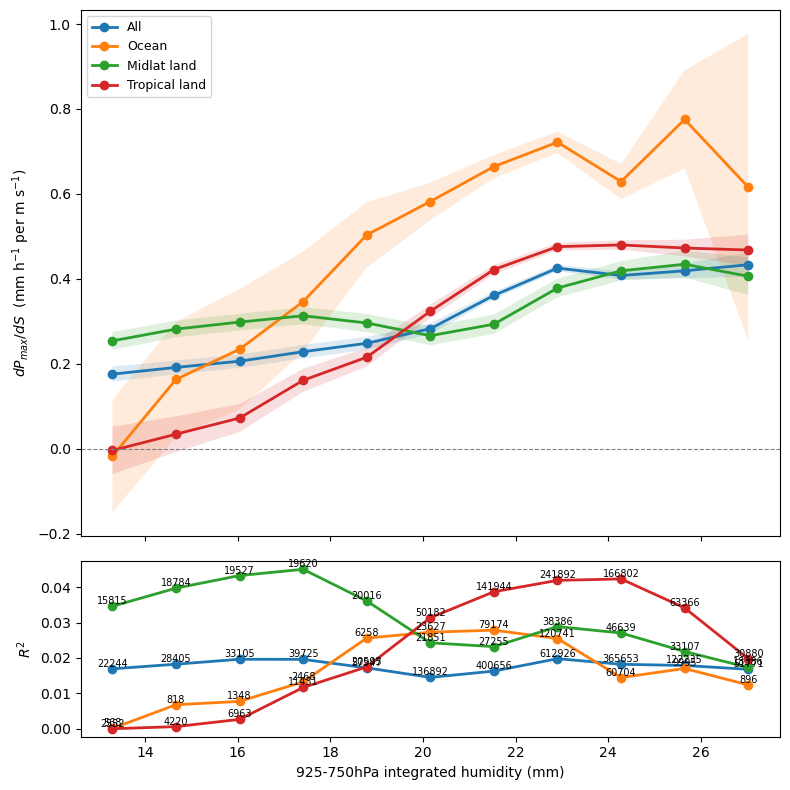

In [25]:
fig, axes = plot_beta_summary_groups(
    {
        "All": beta_all_pr,
        "Ocean": beta_ocean_pr,
        "Midlat land": beta_midlat_pr,
        "Tropical land": beta_tropics_pr,
    },
    ylabel=r"$dP_{max}/dS$  (mm h$^{-1}$ per m s$^{-1}$)",
    xlabel="925-750hPa integrated humidity (mm)",
)

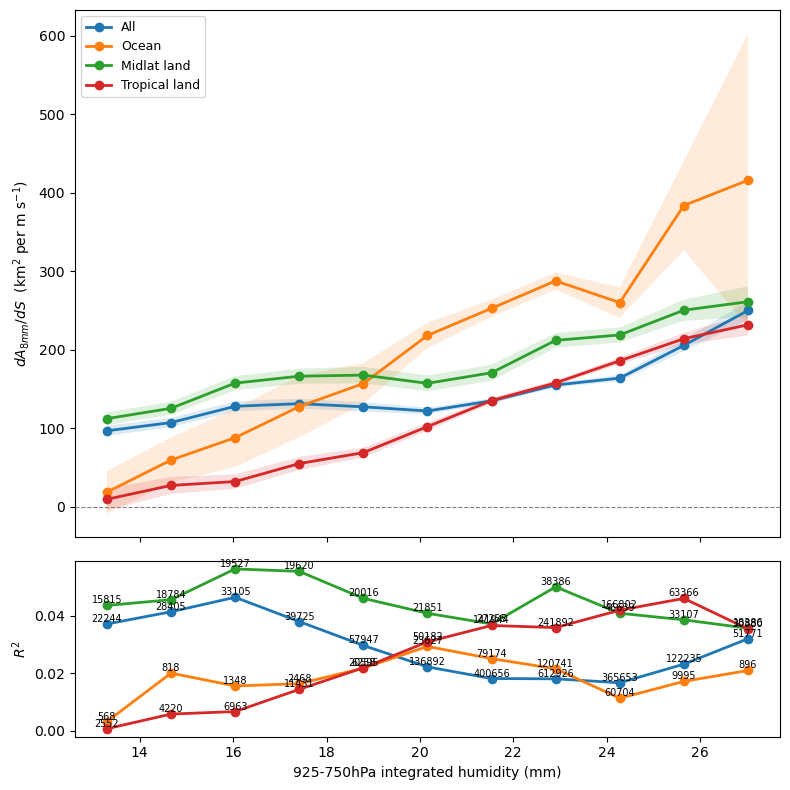

In [30]:
fig, axes = plot_beta_summary_groups(
    {
        "All": beta_all_A,
        "Ocean": beta_ocean_A,
        "Midlat land": beta_midlat_A,
        "Tropical land": beta_tropics_A,
    },
    ylabel=r"$dA_{8mm}/dS$  (km$^2$ per m s$^{-1}$)",
    xlabel="925-750hPa integrated humidity (mm)",
)

In [ ]:
def plot_region_beta_lines(
    beta_df,
    ylabel,
    xlabel="TCWV",
    region_style=None,
    pooled=True,
):
    fig, ax = plt.subplots(figsize=(8, 5))

    use = beta_df.copy()

    # individual regions
    regional = use[use["region"] != "pooled"]

    for region, sub in regional.groupby("region"):
        sub = sub.sort_values("humidity_mid")

        if region_style is not None and region in region_style:
            style = region_style[region]
            color = style.get("color", None)
            ls = style.get("ls", "-")
            label = style.get("label", region)
        else:
            color = None
            ls = "-"
            label = region

        ax.plot(
            sub["humidity_mid"],
            sub["beta"],
            marker="o",
            lw=1.5,
            alpha=0.8,
            color=color,
            linestyle=ls,
            label=label,
        )

    # pooled line on top
    if pooled and "pooled" in use["region"].values:
        p = use[use["region"] == "pooled"].sort_values("humidity_mid")

        ax.plot(
            p["humidity_mid"],
            p["beta"],
            marker="o",
            lw=3,
            color="black",
            label="Pooled",
            zorder=10,
        )

        ax.fill_between(
            p["humidity_mid"],
            p["beta_low95"],
            p["beta_high95"],
            color="black",
            alpha=0.15,
            zorder=9,
        )

    ax.axhline(0, color="0.5", ls="--", lw=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()

    return fig, ax

(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='TCWV (mm)', ylabel='$dP_{max}/dS$  (mm h$^{-1}$ per m s$^{-1}$)'>)

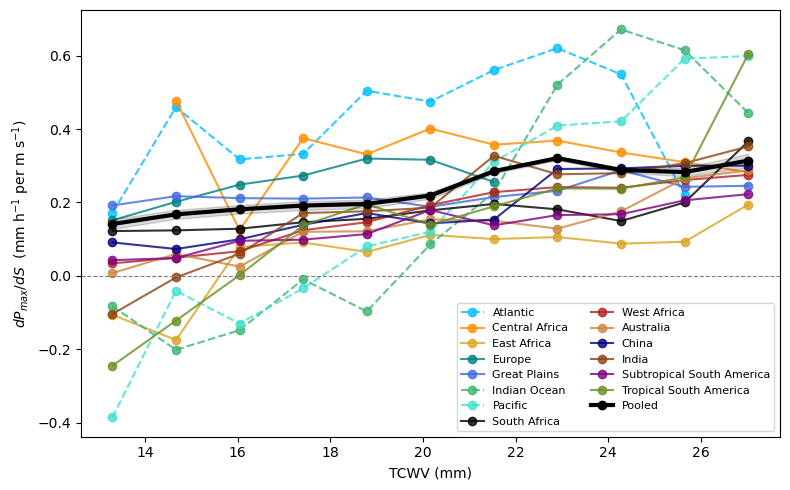

In [20]:

plot_region_beta_lines(
    beta_precip,
    ylabel=r"$dP_{max}/dS$  (mm h$^{-1}$ per m s$^{-1}$)",
    xlabel="TCWV (mm)",
    region_style=style,
)

(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='TCWV (mm)', ylabel='$dA/dS$  (km$^2$ per m s$^{-1}$)'>)

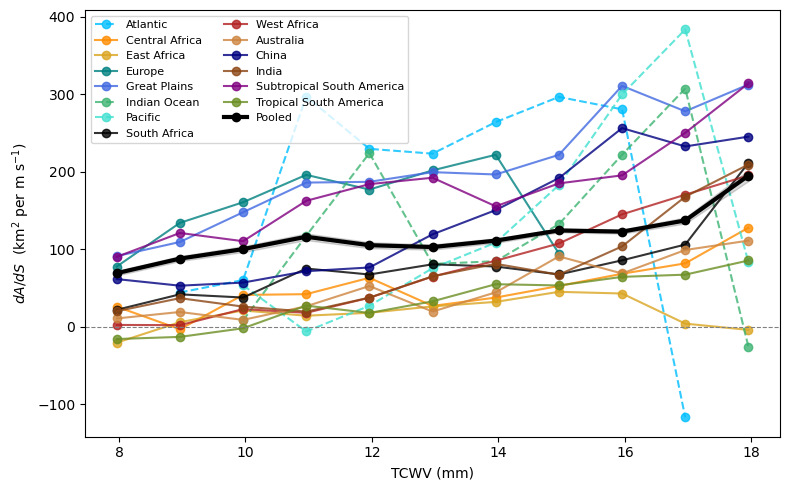

In [52]:
plot_region_beta_lines(
    beta_area,
    ylabel=r"$dA/dS$  (km$^2$ per m s$^{-1}$)",
    xlabel="TCWV (mm)",
    region_style=style,
)

In [53]:
hvar = "q925"
hum_bin = np.linspace(df_env[hvar].quantile(0.02), df_env[hvar].quantile(0.98), 12)  

beta_precip_q925 = compute_beta_table(df_env,humidity_var=hvar,shear_var="shear100_650",
                                      response_var="precipitation_max",humidity_bins=hum_bin,min_n=100)
beta_area50_q925 = compute_beta_table(df_env,humidity_var=hvar,shear_var="shear100_650",
                                      response_var="area50",humidity_bins=hum_bin,min_n=100)
beta_areaP3_q925 = compute_beta_table(df_env,humidity_var=hvar,shear_var="shear100_650",
                                      response_var="precipitation_area3mm",humidity_bins=hum_bin,min_n=100)

In [54]:
hvar = "tcwv"
hum_bin = np.linspace(df_env[hvar].quantile(0.02), df_env[hvar].quantile(0.98), 12)  

beta_precip_tcwv = compute_beta_table(df_env,humidity_var=hvar,shear_var="shear100_650",
                                      response_var="precipitation_max",humidity_bins=hum_bin,min_n=100)
beta_area50_tcwv = compute_beta_table(df_env,humidity_var=hvar,shear_var="shear100_650",
                                      response_var="area50",humidity_bins=hum_bin,min_n=100)
beta_areaP3_tcwv = compute_beta_table(df_env,humidity_var=hvar,shear_var="shear100_650",
                                      response_var="precipitation_area3mm",humidity_bins=hum_bin,min_n=100)

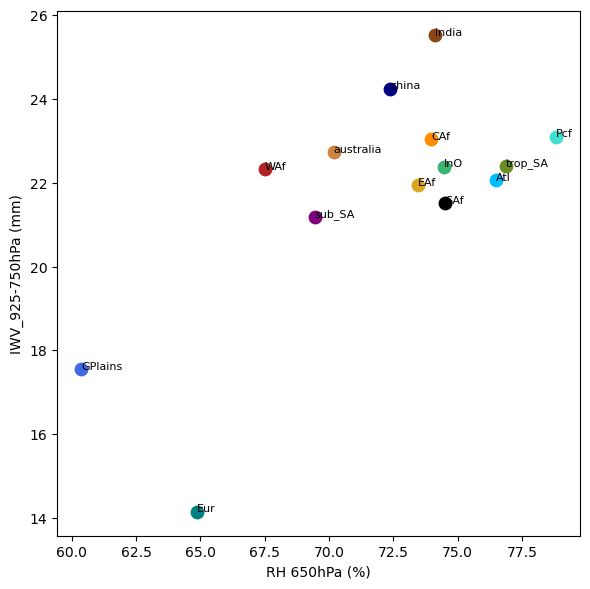

In [40]:
fig, ax = plt.subplots(figsize=(6,6))

for region in REGIONS.keys():

    ax.scatter(
        df_env[df_env['region']==region]['rh650'].mean(),
        df_env[df_env['region']==region]['iwv_925_750'].mean(),
        color=style[region]["color"],
        s=80,
        label=style[region]["label"]
    )

    ax.text(
        df_env[df_env['region']==region]['rh650'].mean(),
        df_env[df_env['region']==region]['iwv_925_750'].mean(),
        region,
        fontsize=8,
    )

# # 1:1 line
# lims = [
#     min(ax.get_xlim()[0], ax.get_ylim()[0]),
#     max(ax.get_xlim()[1], ax.get_ylim()[1]),
# ]

# ax.plot(
#     lims,
#     lims,
#     "--",
#     color="0.5",
#     zorder=0,
# )

# ax.set_xlim(lims)
# ax.set_ylim(lims)

ax.set_xlabel(r"RH 650hPa (%)")
ax.set_ylabel(r"IWV_925-750hPa (mm)")

plt.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def beta_change_by_region(beta_df, low_q=0.2, high_q=0.8):
    """
    Calculates total beta change across humidity range per region.
    Uses low/high quantiles of available humidity_mid values per region
    to avoid relying on noisy edge bins.
    """

    rows = []

    for region, sub in beta_df[beta_df["region"] != "pooled"].groupby("region"):

        sub = sub.dropna(subset=["humidity_mid", "beta"]).sort_values("humidity_mid")

        if len(sub) < 3:
            continue

        low_h = sub["humidity_mid"].quantile(low_q)
        high_h = sub["humidity_mid"].quantile(high_q)

        low = sub.iloc[(sub["humidity_mid"] - low_h).abs().argmin()]
        high = sub.iloc[(sub["humidity_mid"] - high_h).abs().argmin()]

        rows.append({
            "region": region,
            "humidity_low": low["humidity_mid"],
            "humidity_high": high["humidity_mid"],
            "beta_low": low["beta"],
            "beta_high": high["beta"],
            "delta_beta": high["beta"] - low["beta"],
            "n_low": low["n"],
            "n_high": high["n"],
        })

    return pd.DataFrame(rows)

In [52]:
def plot_beta_change_forest(
    beta_pr,
    beta_A,
    region_style=None,
    low_q=0.2,
    high_q=0.8,
    title="Change in shear sensitivity across humidity range",
):

    pr = beta_change_by_region(beta_pr, low_q=low_q, high_q=high_q)
    ar = beta_change_by_region(beta_A, low_q=low_q, high_q=high_q)

    regions = sorted(set(pr["region"]) | set(ar["region"]))
    y = np.arange(len(regions))

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 0.45 * len(regions) + 2),
        sharey=True,
    )

    for ax, data, xlabel in zip(
        axes,
        [pr, ar],
        [
            r"$\Delta(dP_{max}/dS)$ (mm h$^{-1}$/ m s$^{-1}$)",
            r"$\Delta(dA/dS)$ (km$^{2}$/ m s$^{-1}$)",
        ],
    ):

        for i, region in enumerate(regions):

            row = data[data["region"] == region]
            if len(row) == 0:
                continue

            row = row.iloc[0]

            color = (
                region_style.get(region, {}).get("color", "black")
                if region_style is not None else "black"
            )

            ax.scatter(
                row["delta_beta"],
                i,
                color=color,
                s=70,
                zorder=3,
            )

            ax.plot(
                [0, row["delta_beta"]],
                [i, i],
                color=color,
                lw=2,
                alpha=0.7,
            )

        ax.axvline(0, color="0.5", ls="--", lw=0.8)
        ax.set_xlabel(xlabel)
        ax.grid(axis="x", alpha=0.25)

    axes[0].set_yticks(y)

    if region_style is not None:
        axes[0].set_yticklabels([
            region_style.get(r, {}).get("label", r)
            for r in regions
        ])
    else:
        axes[0].set_yticklabels(regions)

    fig.suptitle(title)
    plt.tight_layout()

    return fig, axes

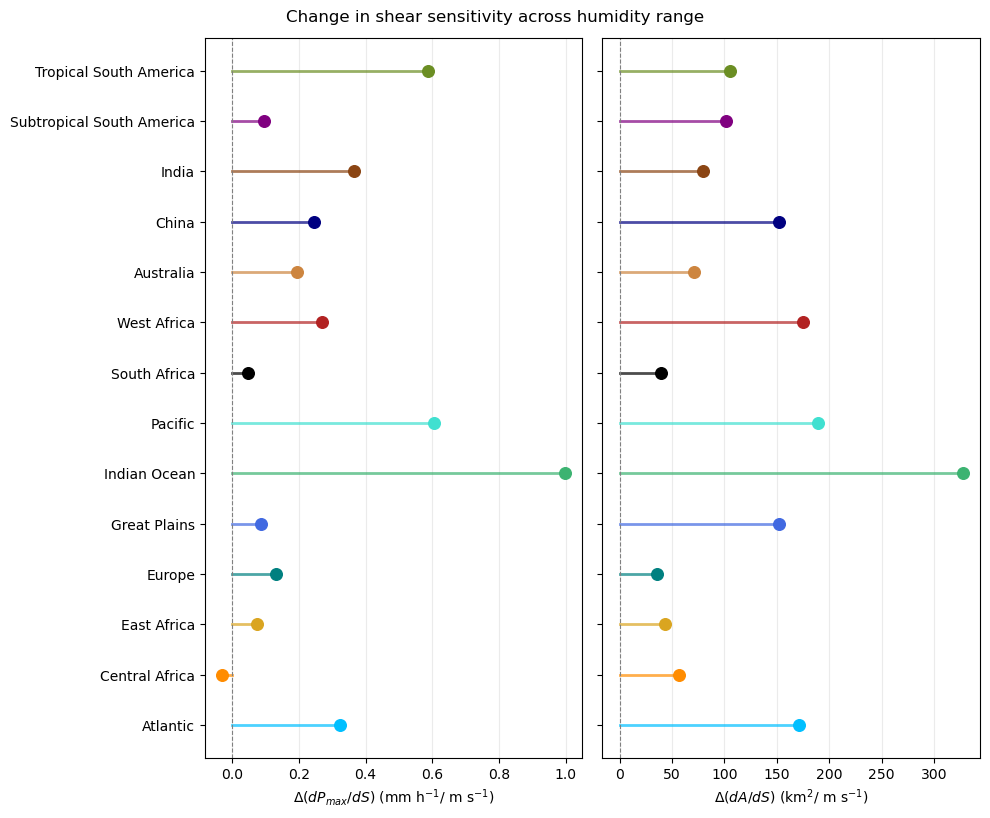

In [53]:
fig, axes = plot_beta_change_forest(
    beta_all_pr,
    beta_all_A,
    region_style=style,
)

In [54]:
import numpy as np
import pandas as pd
from scipy.stats import linregress


def beta_humidity_slope_by_region(beta_df, min_bins=3):
    """
    Fits beta = a + b * humidity_mid for each region.

    b = d(beta) / d(humidity)

    Returns one row per region.
    """

    rows = []

    for region, sub in beta_df[beta_df["region"] != "pooled"].groupby("region"):

        sub = (
            sub
            .dropna(subset=["humidity_mid", "beta"])
            .sort_values("humidity_mid")
        )

        if len(sub) < min_bins:
            continue

        fit = linregress(
            sub["humidity_mid"],
            sub["beta"],
        )

        rows.append({
            "region": region,

            # main quantity
            "dbeta_dhumidity": fit.slope,
            "dbeta_dhumidity_stderr": fit.stderr,
            "dbeta_dhumidity_low95": fit.slope - 1.96 * fit.stderr,
            "dbeta_dhumidity_high95": fit.slope + 1.96 * fit.stderr,

            # diagnostics
            "intercept": fit.intercept,
            "r": fit.rvalue,
            "r2": fit.rvalue**2,
            "p": fit.pvalue,
            "n_bins": len(sub),

            # useful metadata
            "humidity_min": sub["humidity_mid"].min(),
            "humidity_max": sub["humidity_mid"].max(),
            "beta_min": sub["beta"].min(),
            "beta_max": sub["beta"].max(),
            "beta_first": sub.iloc[0]["beta"],
            "beta_last": sub.iloc[-1]["beta"],
            "delta_beta_range": sub.iloc[-1]["beta"] - sub.iloc[0]["beta"],
        })

    return pd.DataFrame(rows)

In [55]:
slope_pr = beta_humidity_slope_by_region(beta_all_pr)
slope_A = beta_humidity_slope_by_region(beta_all_A)

In [56]:
import matplotlib.pyplot as plt


def plot_dbeta_dhumidity_forest(
    slope_pr,
    slope_A,
    region_style=None,
    title=r"Change in shear sensitivity per unit humidity",
):

    regions = sorted(set(slope_pr["region"]) | set(slope_A["region"]))
    y = np.arange(len(regions))

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 0.45 * len(regions) + 2),
        sharey=True,
    )

    for ax, data, xlabel in zip(
        axes,
        [slope_pr, slope_A],
        [
            r"$d\beta_P/dQ$",
            r"$d\beta_A/dQ$",
        ],
    ):

        for i, region in enumerate(regions):

            row = data[data["region"] == region]

            if len(row) == 0:
                continue

            row = row.iloc[0]

            color = (
                region_style.get(region, {}).get("color", "black")
                if region_style is not None
                else "black"
            )

            ax.errorbar(
                row["dbeta_dhumidity"],
                i,
                xerr=[
                    [row["dbeta_dhumidity"] - row["dbeta_dhumidity_low95"]],
                    [row["dbeta_dhumidity_high95"] - row["dbeta_dhumidity"]],
                ],
                fmt="o",
                color=color,
                capsize=3,
                markersize=6,
            )

        ax.axvline(0, color="0.5", ls="--", lw=0.8)
        ax.set_xlabel(xlabel)
        ax.grid(axis="x", alpha=0.25)

    axes[0].set_yticks(y)

    if region_style is not None:
        axes[0].set_yticklabels([
            region_style.get(r, {}).get("label", r)
            for r in regions
        ])
    else:
        axes[0].set_yticklabels(regions)

    fig.suptitle(title)
    plt.tight_layout()

    return fig, axes

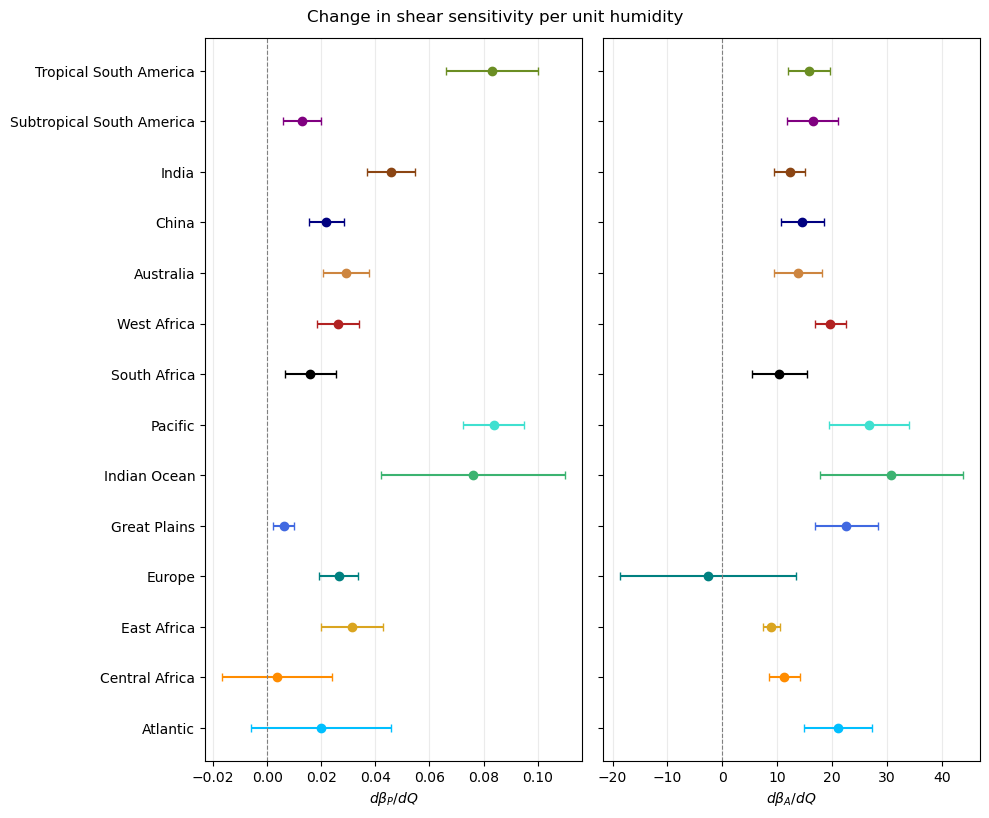

In [58]:
fig, axes = plot_dbeta_dhumidity_forest(
    slope_pr,
    slope_A,
    region_style=style,
)

In [119]:
import numpy as np
import pandas as pd
from scipy.stats import linregress


def compute_percent_added_growth_high_vs_low_humidity(
    df,
    humidity_var="tcwv",
    shear_var="shear100_650",
    response_var="area",
    low_humidity_q=0.3,
    high_humidity_q=0.7,
    shear_low_q=0.01,
    shear_high_q=0.99,
    min_n=100,
    min_abs_low_response=1e-6,
):
    rows = []

    for region, rdf in df.groupby("region"):

        rdf = rdf.dropna(
            subset=[humidity_var, shear_var, response_var]
        ).copy()

        if len(rdf) < 2 * min_n:
            continue

        # humidity thresholds per region
        h_low_thr = rdf[humidity_var].quantile(low_humidity_q)
        h_high_thr = rdf[humidity_var].quantile(high_humidity_q)

        low_h = rdf[rdf[humidity_var] <= h_low_thr]
        high_h = rdf[rdf[humidity_var] >= h_high_thr]

        if len(low_h) < min_n or len(high_h) < min_n:
            continue

        # same shear range for both humidity subsets, per region
        s_low = rdf[shear_var].quantile(shear_low_q)
        s_high = rdf[shear_var].quantile(shear_high_q)
        delta_shear = s_high - s_low

        if delta_shear <= 0:
            continue

        # fit beta in low humidity subset
        fit_low = linregress(
            low_h[shear_var],
            low_h[response_var],
        )

        # fit beta in high humidity subset
        fit_high = linregress(
            high_h[shear_var],
            high_h[response_var],
        )

        beta_low = fit_low.slope
        beta_high = fit_high.slope

        # response increase from low to high shear
        response_increase_low_h = beta_low * delta_shear
        response_increase_high_h = beta_high * delta_shear

        if abs(response_increase_low_h) < min_abs_low_response:
            pct_added_growth = np.nan
        else:
            pct_added_growth = (
                100
                * (response_increase_high_h - response_increase_low_h)
                / abs(response_increase_low_h)
            )

        rows.append({
            "region": region,

            "response_var": response_var,
            "humidity_var": humidity_var,
            "shear_var": shear_var,

            "humidity_low_threshold": h_low_thr,
            "humidity_high_threshold": h_high_thr,

            "shear_low_value": s_low,
            "shear_high_value": s_high,
            "delta_shear": delta_shear,

            "beta_low_humidity": beta_low,
            "beta_high_humidity": beta_high,
            "delta_beta": beta_high - beta_low,

            "response_increase_low_humidity": response_increase_low_h,
            "response_increase_high_humidity": response_increase_high_h,
            "delta_response_increase": (
                response_increase_high_h - response_increase_low_h
            ),

            "pct_added_growth_high_vs_low_humidity": pct_added_growth,

            "r_low": fit_low.rvalue,
            "r_high": fit_high.rvalue,
            "r2_low": fit_low.rvalue**2,
            "r2_high": fit_high.rvalue**2,
            "p_low": fit_low.pvalue,
            "p_high": fit_high.pvalue,

            "n_low_humidity": len(low_h),
            "n_high_humidity": len(high_h),
            "n_total_region": len(rdf),
        })

    return pd.DataFrame(rows)

In [120]:
A_growth = compute_percent_added_growth_high_vs_low_humidity(
    df_env,
    humidity_var="iwv_925_750",
    shear_var="shear100_650",
    response_var="precipitation_area8mm",
)

P_growth = compute_percent_added_growth_high_vs_low_humidity(
    df_env,
    humidity_var="iwv_925_750",
    shear_var="shear100_650",
    response_var="precipitation_max",
)

In [121]:
def plot_added_growth(
    growth_df,
    value_col="pct_added_growth_high_vs_low_humidity",
    label="storm area",
    region_style=None,
):
    use = growth_df.sort_values(value_col).copy()
    y = np.arange(len(use))

    fig, ax = plt.subplots(figsize=(8, 0.45 * len(use) + 2))

    for i, row in enumerate(use.itertuples()):

        region = row.region

        color = (
            region_style.get(region, {}).get("color", "black")
            if region_style is not None else "black"
        )

        ax.plot(
            [0, getattr(row, value_col)],
            [i, i],
            color=color,
            lw=2,
            alpha=0.7,
        )

        ax.scatter(
            getattr(row, value_col),
            i,
            color=color,
            s=70,
            zorder=3,
        )

        ax.text(
            getattr(row, value_col),
            i,
            f"  ΔS={row.delta_shear:.1f}",
            va="center",
            fontsize=8,
        )

    ax.axvline(0, color="0.5", ls="--", lw=0.8)

    ax.set_yticks(y)

    ax.set_yticklabels([
        region_style.get(r, {}).get("label", r)
        if region_style is not None else r
        for r in use["region"]
    ])

    ax.set_xlabel(
        f"% added shear-driven {label} response\n"
        "in humid vs dry environments"
    )

    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    return fig, ax

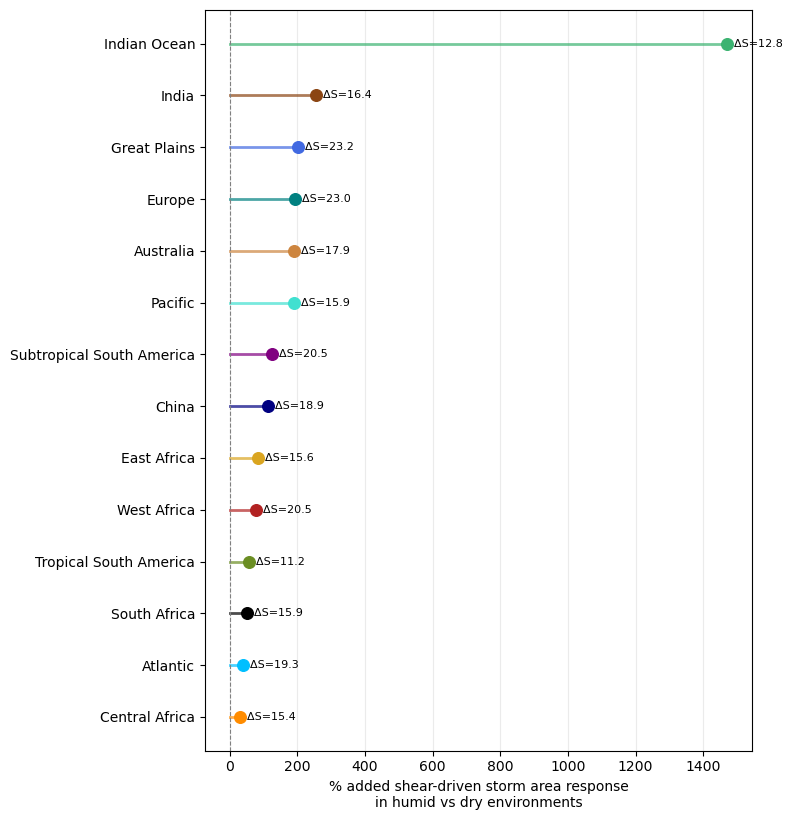

In [122]:
fig, ax = plot_added_growth(
    A_growth,
    label="storm area",
    region_style=style,
)

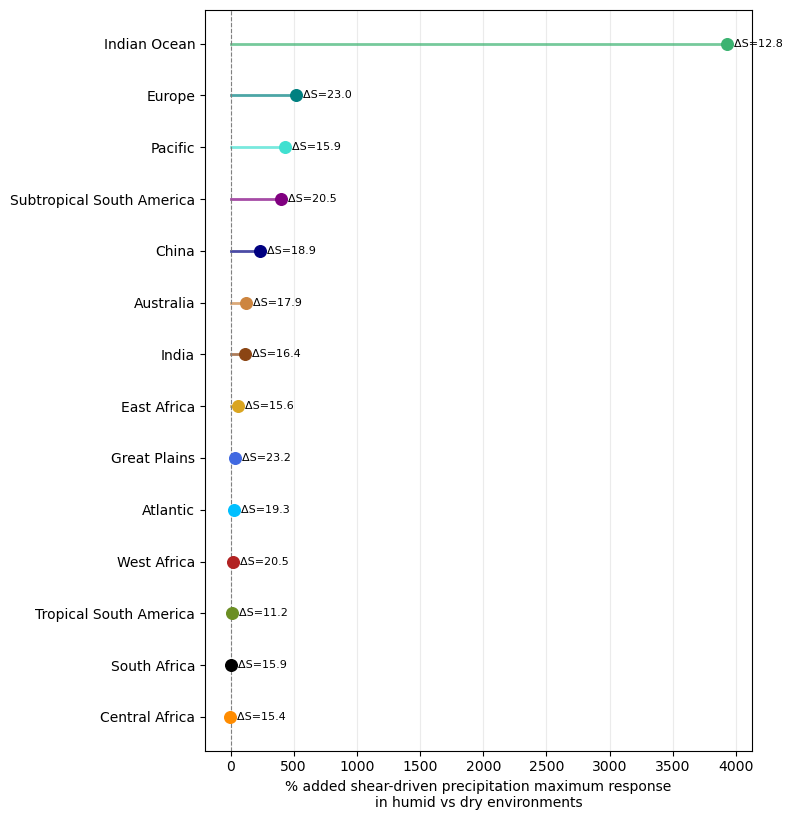

In [104]:
fig, ax = plot_added_growth(
    P_growth,
    label="precipitation maximum",
    region_style=style,
)

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_shear_response_percent(
    df,
    humidity_var="tcwv",
    shear_var="shear100_650",
    response_var="area",
    low_humidity_q=0.3,
    high_humidity_q=0.70,
    low_shear_q=0.01,
    high_shear_q=0.99,
    min_n=50,
):
    rows = []

    for region, rdf in df.groupby("region"):

        rdf = rdf.dropna(
            subset=[humidity_var, shear_var, response_var]
        ).copy()

        # clip 1st-99th percentile for all analysis variables
        for var in [humidity_var, shear_var, response_var]:

            p1 = rdf[var].quantile(0.01)
            p99 = rdf[var].quantile(0.99)

            rdf = rdf[
                (rdf[var] >= p1) &
                (rdf[var] <= p99)
    ]

        if len(rdf) < 4 * min_n:
            continue

        # region-specific thresholds
        h_low = rdf[humidity_var].quantile(low_humidity_q)
        h_high = rdf[humidity_var].quantile(high_humidity_q)

        s_low = rdf[shear_var].quantile(low_shear_q)
        s_high = rdf[shear_var].quantile(high_shear_q)

        groups = {
            "dry_low_shear": rdf[
                (rdf[humidity_var] <= h_low) &
                (rdf[shear_var] <= s_low)
            ],
            "dry_high_shear": rdf[
                (rdf[humidity_var] <= h_low) &
                (rdf[shear_var] >= s_high)
            ],
            "humid_low_shear": rdf[
                (rdf[humidity_var] >= h_high) &
                (rdf[shear_var] <= s_low)
            ],
            "humid_high_shear": rdf[
                (rdf[humidity_var] >= h_high) &
                (rdf[shear_var] >= s_high)
            ],
        }

        if any(len(g) < min_n for g in groups.values()):
            print(region, "skipped: too few storms in one corner")
            continue

        means = {
            name: g[response_var].mean()
            for name, g in groups.items()
        }

        counts = {
            name + "_n": len(g)
            for name, g in groups.items()
        }

        dry_shear_pct = (
            100
            * (means["dry_high_shear"] - means["dry_low_shear"])
            / means["dry_low_shear"]
        )

        humid_shear_pct = (
            100
            * (means["humid_high_shear"] - means["humid_low_shear"])
            / means["humid_low_shear"]
        )

        rows.append({
            "region": region,
            "response_var": response_var,
            "humidity_var": humidity_var,
            "shear_var": shear_var,

            "humidity_low_threshold": h_low,
            "humidity_high_threshold": h_high,
            "shear_low_threshold": s_low,
            "shear_high_threshold": s_high,
            "delta_shear_threshold": s_high - s_low,

            "dry_low_shear_mean": means["dry_low_shear"],
            "dry_high_shear_mean": means["dry_high_shear"],
            "humid_low_shear_mean": means["humid_low_shear"],
            "humid_high_shear_mean": means["humid_high_shear"],

            "dry_shear_pct": dry_shear_pct,
            "humid_shear_pct": humid_shear_pct,
            "humid_minus_dry_pct_points": humid_shear_pct - dry_shear_pct,

            "humid_vs_dry_relative_gain": (
                100
                * (humid_shear_pct - dry_shear_pct)
                / abs(dry_shear_pct)
                if abs(dry_shear_pct) > 1e-6 else np.nan
            ),

            **counts,
        })

    return pd.DataFrame(rows)

In [124]:
A_shear_pct = compute_shear_response_percent(
    df_env,
    humidity_var="iwv_925_750",
    shear_var="shear100_650",
    response_var="precipitation_area8mm",
)

P_shear_pct = compute_shear_response_percent(
    df_env,
    humidity_var="iwv_925_750",
    shear_var="shear100_650",
    response_var="precipitation_max",
)

In [125]:
def plot_shear_response_percent(
    result_df,
    response_label="storm area",
    region_style=None,
):
    use = result_df.sort_values("humid_minus_dry_pct_points").copy()
    y = np.arange(len(use))

    fig, ax = plt.subplots(figsize=(8, 0.45 * len(use) + 2))

    for i, row in enumerate(use.itertuples()):

        region = row.region

        color = (
            region_style.get(region, {}).get("color", "black")
            if region_style is not None else "black"
        )

        # line from dry response to humid response
        ax.plot(
            [row.dry_shear_pct, row.humid_shear_pct],
            [i, i],
            color=color,
            lw=2,
            alpha=0.7,
        )

        ax.scatter(
            row.dry_shear_pct,
            i,
            color=color,
            marker="o",
            s=55,
            label=None,
        )

        ax.scatter(
            row.humid_shear_pct,
            i,
            color=color,
            marker="s",
            s=65,
            label=None,
        )

        ax.text(
            max(row.dry_shear_pct, row.humid_shear_pct),
            i,
            f"  Δ={row.humid_minus_dry_pct_points:.0f} pp",
            va="center",
            fontsize=8,
        )

    ax.axvline(0, color="0.5", ls="--", lw=0.8)

    ax.set_yticks(y)
    ax.set_yticklabels([
        region_style.get(r, {}).get("label", r)
        if region_style is not None else r
        for r in use["region"]
    ])

    ax.set_xlabel(
        f"% increase in {response_label} from low to high shear\n"
        "circle = driest 20%, square = most humid 20%"
    )

    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    return fig, ax

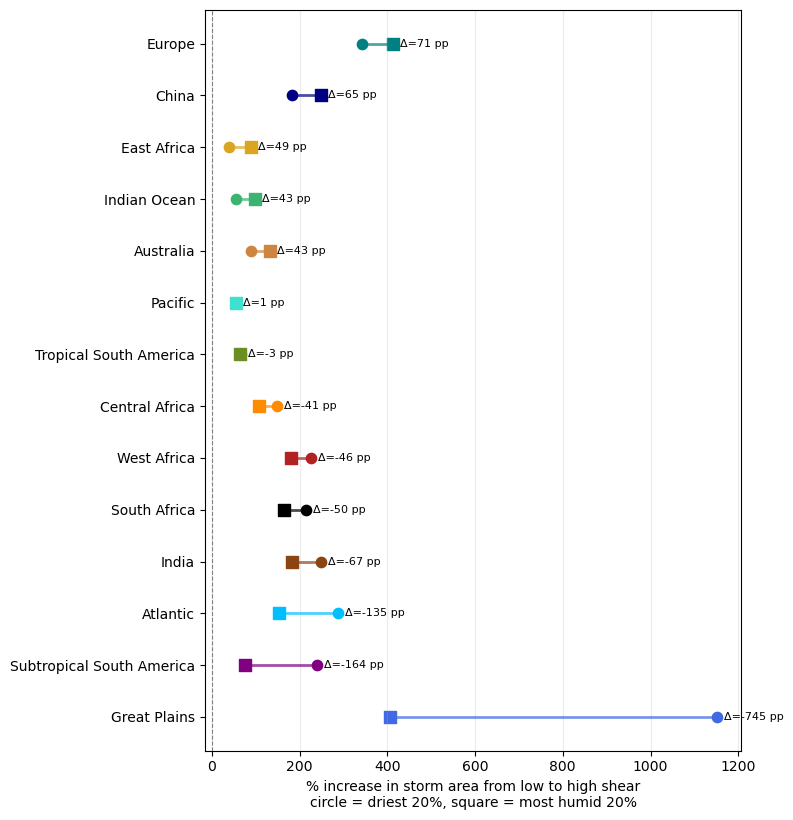

In [126]:
fig, ax = plot_shear_response_percent(
    A_shear_pct,
    response_label="storm area",
    region_style=style,
)

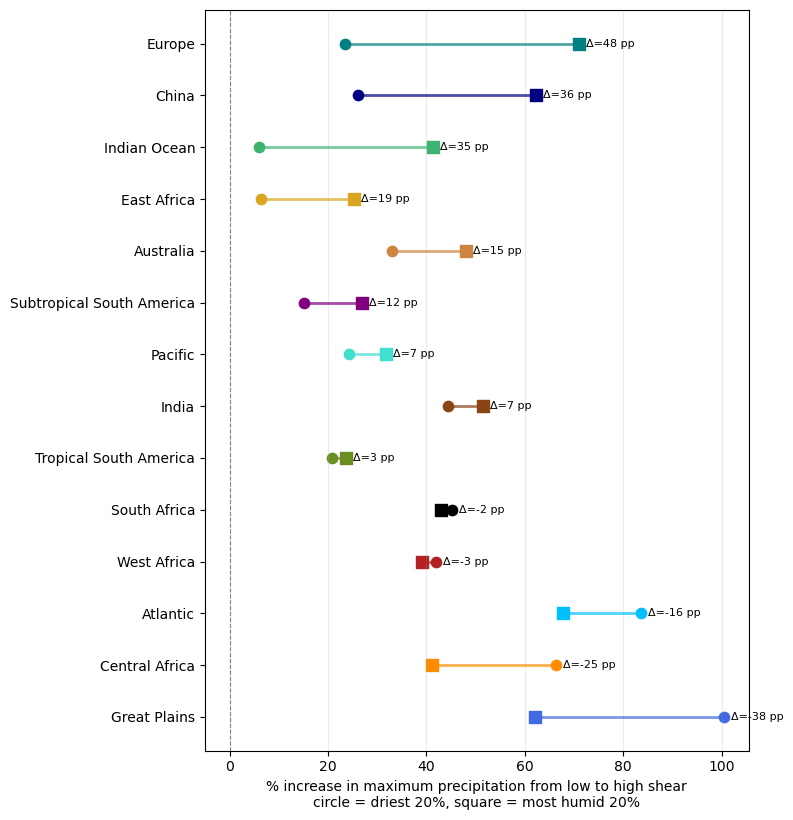

In [127]:
fig, ax = plot_shear_response_percent(
    P_shear_pct,
    response_label="maximum precipitation",
    region_style=style,
)

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

def compute_beta_terciles_by_region(
    df,
    humidity_var="tcwv",
    shear_var="shear100_650",
    response_var="area",
    clip_quantiles=(0.01, 0.99),
    min_n=100,
):
    rows = []

    for region, rdf in df.groupby("region"):

        rdf = rdf.dropna(
            subset=[humidity_var, shear_var, response_var]
        ).copy()

        # clip weird tails per region
        if clip_quantiles is not None:
            qlo, qhi = clip_quantiles

            for var in [humidity_var, shear_var, response_var]:
                lo = rdf[var].quantile(qlo)
                hi = rdf[var].quantile(qhi)
                rdf = rdf[rdf[var].between(lo, hi)]

        if len(rdf) < 3 * min_n:
            continue

        # tercile thresholds after clipping
        h1 = rdf[humidity_var].quantile(1/3)
        h2 = rdf[humidity_var].quantile(2/3)

        bins = {
            "low": rdf[rdf[humidity_var] <= h1],
            "mid": rdf[(rdf[humidity_var] > h1) & (rdf[humidity_var] <= h2)],
            "high": rdf[rdf[humidity_var] > h2],
        }

        for hclass, sub in bins.items():

            if len(sub) < min_n:
                continue

            if sub[shear_var].nunique() < 2:
                continue

            fit = linregress(
                sub[shear_var],
                sub[response_var],
            )

            rows.append({
                "region": region,
                "humidity_bin": hclass,
                "beta": fit.slope,
                "beta_stderr": fit.stderr,
                "beta_low95": fit.slope - 1.96 * fit.stderr,
                "beta_high95": fit.slope + 1.96 * fit.stderr,
                "r": fit.rvalue,
                "r2": fit.rvalue**2,
                "p": fit.pvalue,
                "n": len(sub),
                "humidity_mean": sub[humidity_var].mean(),
                "humidity_min": sub[humidity_var].min(),
                "humidity_max": sub[humidity_var].max(),
                "response_var": response_var,
            })

    return pd.DataFrame(rows)

In [64]:
beta_tercile_A = compute_beta_terciles_by_region(
    df_env,
    humidity_var="tcwv",
    shear_var="shear100_650",
    response_var="area50",
)

beta_tercile_P = compute_beta_terciles_by_region(
    df_env,
    humidity_var="tcwv",
    shear_var="shear100_650",
    response_var="precipitation_max",
)

In [65]:
def plot_beta_tercile_bars(
    beta_df,
    ylabel,
    region_style=None,
    title=None,
):
    order = ["low", "mid", "high"]

    # ColorBrewer-ish YlGnBu sequence
    colors = {
        "low":  "#a1dab4",
        "mid":  "#41b6c4",
        "high": "#225ea8",
    }

    regions = sorted(beta_df["region"].unique())
    x = np.arange(len(regions))
    width = 0.25

    fig, ax = plt.subplots(figsize=(0.65 * len(regions) + 3, 5))

    for i, hbin in enumerate(order):

        sub = (
            beta_df[beta_df["humidity_bin"] == hbin]
            .set_index("region")
            .reindex(regions)
        )

        xpos = x + (i - 1) * width

        ax.bar(
            xpos,
            sub["beta"],
            width=width,
            yerr=[
                sub["beta"] - sub["beta_low95"],
                sub["beta_high95"] - sub["beta"],
            ],
            capsize=3,
            label=hbin.capitalize(),
            color=colors[hbin],
            edgecolor="0.2",
            linewidth=0.5,
        )

    ax.axhline(0, color="0.4", ls="--", lw=0.8)

    ax.set_xticks(x)

    labels = [
        region_style.get(r, {}).get("label", r)
        if region_style is not None else r
        for r in regions
    ]

    ax.set_xticklabels(labels, rotation=45, ha="right")

    ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

    ax.legend(title="Humidity tercile", frameon=False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.tight_layout()
    #fig.savefig(paths.shear_figs + '/2d_hist_area-50_tcwv_cp4.png')
    return fig, ax

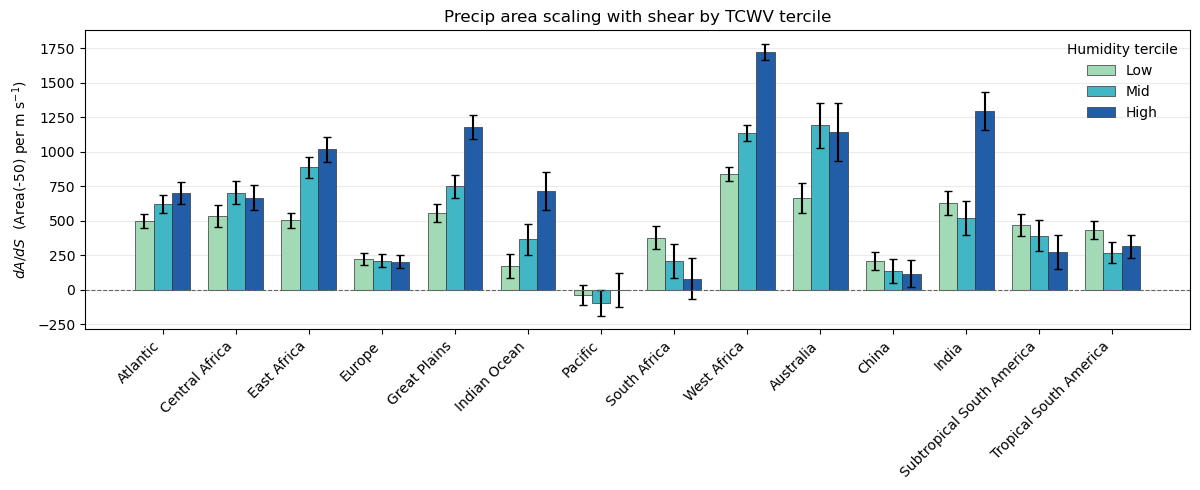

In [66]:
fig, ax = plot_beta_tercile_bars(
    beta_tercile_A,
    ylabel=r"$dA/dS$  (Area(-50) per m s$^{-1}$)",
    region_style=style,
    title="Precip area scaling with shear by TCWV tercile",
)

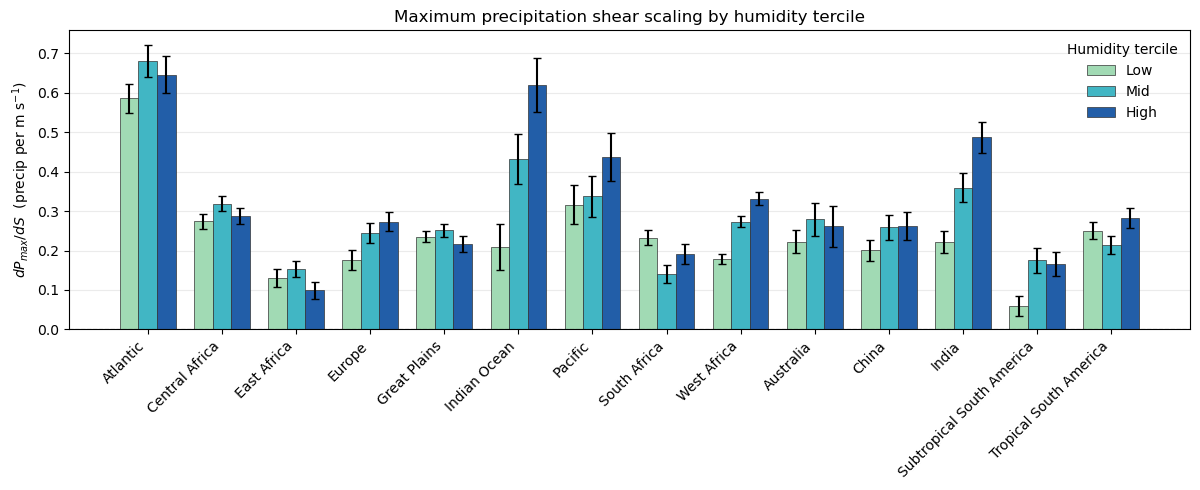

In [56]:
fig, ax = plot_beta_tercile_bars(
    beta_tercile_P,
    ylabel=r"$dP_{max}/dS$  (precip per m s$^{-1}$)",
    region_style=style,
    title="Maximum precipitation shear scaling by humidity tercile",
)